# 03 — Noise Oscillators

Covers `caspy.noise.NoiseOscillatorWhite` and `NoiseOscillatorPink`.

**Sections:**
1. Generate and plot white noise
2. Spectral analysis — power spectrum density
3. White vs pink — spectral comparison
4. Seed reproducibility
5. Amplitude modulation via `ModulatableParameter`
6. Interactive: tune amplitude and seed, hear the difference
7. Live audio playback

In [4]:
import caspy as cp
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Audio
from scipy.signal import welch

SR = 44100
print('caspy loaded')

caspy loaded


## 1. White noise — time domain

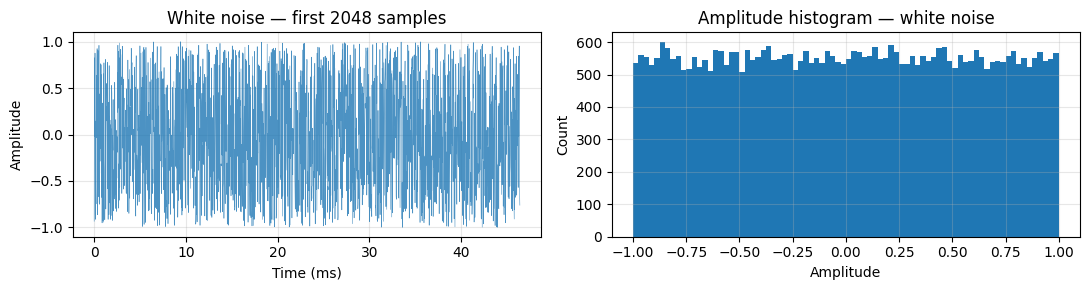

DC:    -0.00019   (should be ≈0)
Peak:  1.0000  (should be ≤1)
σ:     0.5765


In [6]:
osc_white = cp.noise.NoiseOscillatorWhite(float(SR))
buf_white = osc_white.render(SR)  # 1 s

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].plot(np.arange(2048) / SR * 1000, buf_white[:2048], linewidth=0.4, alpha=0.8)
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('White noise — first 2048 samples')
axes[0].set_ylim(-1.1, 1.1)
axes[0].grid(True, alpha=0.3)

axes[1].hist(buf_white, bins=80, edgecolor='none')
axes[1].set_xlabel('Amplitude')
axes[1].set_ylabel('Count')
axes[1].set_title('Amplitude histogram — white noise')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'DC:    {buf_white.mean():.5f}   (should be ≈0)')
print(f'Peak:  {np.abs(buf_white).max():.4f}  (should be ≤1)')
print(f'σ:     {buf_white.std():.4f}')

## 2. Power spectral density — white vs pink

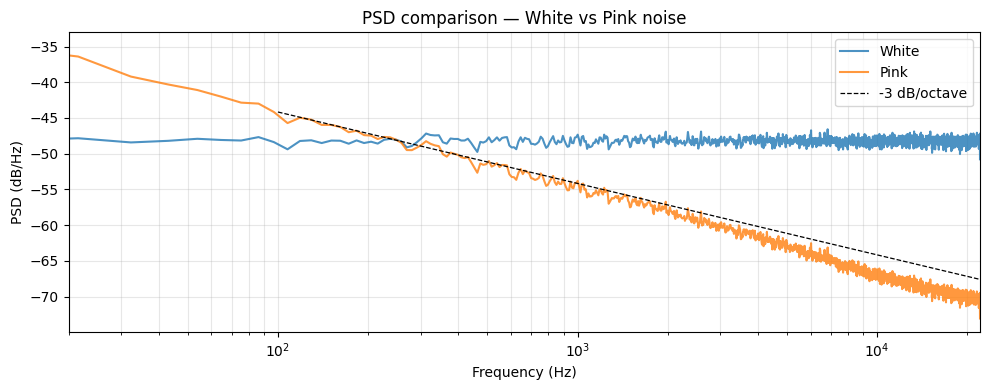

In [7]:
osc_pink  = cp.noise.NoiseOscillatorPink(float(SR))
buf_pink  = osc_pink.render(SR * 4)  # 4 s for better frequency resolution
buf_white2 = cp.noise.NoiseOscillatorWhite(float(SR)).render(SR * 4)

f_w, psd_w = welch(buf_white2, fs=SR, nperseg=4096)
f_p, psd_p = welch(buf_pink,   fs=SR, nperseg=4096)

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogx(f_w[1:], 10 * np.log10(psd_w[1:]), alpha=0.8, label='White')
ax.semilogx(f_p[1:], 10 * np.log10(psd_p[1:]), alpha=0.8, label='Pink')

# Theoretical -3 dB/octave reference line for pink noise
f_ref  = np.array([100.0, SR / 2])
psd_ref_db = 10 * np.log10(psd_p[np.argmin(np.abs(f_p - 100))]) \
             - 10 * np.log10(f_ref / 100)  # -10 dB/decade = -3 dB/octave
ax.semilogx(f_ref, psd_ref_db, 'k--', linewidth=0.9, label='-3 dB/octave')

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD (dB/Hz)')
ax.set_title('PSD comparison — White vs Pink noise')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim(20, SR / 2)
plt.tight_layout()
plt.show()

## 3. Octave-band energy — verify -3 dB/octave rolloff

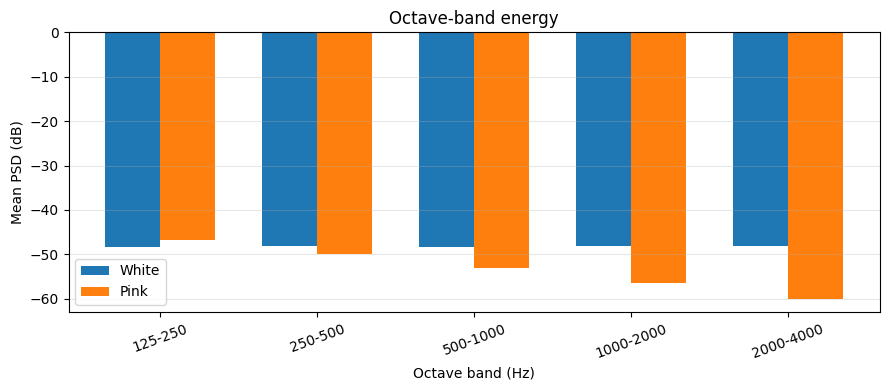

Pink: octave-to-octave ratios (should be < 1 = falling):
  125-250 → 250-500: 0.492  (-3.1 dB)
  250-500 → 500-1000: 0.475  (-3.2 dB)
  500-1000 → 1000-2000: 0.479  (-3.2 dB)
  1000-2000 → 2000-4000: 0.438  (-3.6 dB)


In [8]:
octave_bands = [(125, 250), (250, 500), (500, 1000), (1000, 2000), (2000, 4000)]

def band_energy(psd, freqs, lo, hi):
    mask = (freqs >= lo) & (freqs < hi)
    return psd[mask].mean()

white_energy = [band_energy(psd_w, f_w, lo, hi) for lo, hi in octave_bands]
pink_energy  = [band_energy(psd_p, f_p, lo, hi) for lo, hi in octave_bands]

labels = [f'{lo}-{hi}' for lo, hi in octave_bands]
x      = np.arange(len(labels))
width  = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - width/2, 10*np.log10(np.array(white_energy)), width, label='White')
ax.bar(x + width/2, 10*np.log10(np.array(pink_energy)),  width, label='Pink')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20)
ax.set_xlabel('Octave band (Hz)')
ax.set_ylabel('Mean PSD (dB)')
ax.set_title('Octave-band energy')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print('Pink: octave-to-octave ratios (should be < 1 = falling):')
for i in range(1, len(pink_energy)):
    ratio = pink_energy[i] / pink_energy[i-1]
    print(f'  {labels[i-1]} → {labels[i]}: {ratio:.3f}  ({10*np.log10(ratio):.1f} dB)')

## 4. Seed reproducibility

Same seed identical:    True
Different seed differs: True


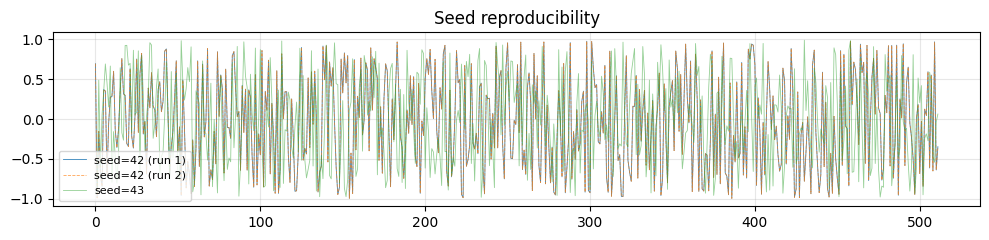

In [9]:
seed = 42
n    = 512

a = cp.noise.NoiseOscillatorWhite(float(SR))
b = cp.noise.NoiseOscillatorWhite(float(SR))

a.seed(seed)
b.seed(seed)
buf_a = a.render(n)
buf_b = b.render(n)

# Different seed
c = cp.noise.NoiseOscillatorWhite(float(SR))
c.seed(seed + 1)
buf_c = c.render(n)

print(f'Same seed identical:    {np.array_equal(buf_a, buf_b)}')
print(f'Different seed differs: {not np.array_equal(buf_a, buf_c)}')

fig, ax = plt.subplots(figsize=(10, 2.5))
t = np.arange(n)
ax.plot(t, buf_a, linewidth=0.6, label='seed=42 (run 1)', alpha=0.9)
ax.plot(t, buf_b, linewidth=0.6, linestyle='--', label='seed=42 (run 2)', alpha=0.7)
ax.plot(t, buf_c, linewidth=0.6, alpha=0.5, label='seed=43')
ax.set_title('Seed reproducibility')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Amplitude modulation

In [13]:
# Gate-like envelope: use LFO square wave at 4 Hz to amplitude-modulate noise
n    = SR * 2
gate_lfo = cp.lfo.LFO(float(SR), 4.0, cp.lfo.LfoShape.Square, cp.lfo.LfoOutputMode.Unipolar)
osc  = cp.noise.NoiseOscillatorWhite(float(SR))

out = np.empty(n, dtype=np.float32)
for i in range(n):
    gate = gate_lfo.render_sample()
    osc.amplitude.clear_modulation()
    # Map gate [0,1] → amplitude: use as direct normalised value
    osc.amplitude.add_modulation(gate - 1.0)  # shift: base=1, mod pulls to 0
    out[i] = osc.render_sample()

t_ms = np.arange(n) / SR * 1000
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t_ms, out, linewidth=0.3, alpha=0.8)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Amplitude')
ax.set_title('White noise gated by 4 Hz square LFO')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

TypeError: __init__(): incompatible constructor arguments. The following argument types are supported:
    1. caspy.lfo.LFO()
    2. caspy.lfo.LFO(sample_rate: typing.SupportsFloat | typing.SupportsIndex, rate_hz: typing.SupportsFloat | typing.SupportsIndex)

Invoked with: 44100.0, 4.0, <LfoShape.Square: 4>, <LfoOutputMode.Unipolar: 1>

## 6. Interactive: white vs pink, amplitude, seed

In [11]:
w_type  = widgets.ToggleButtons(options=['White', 'Pink'], description='Type')
w_amp   = widgets.FloatSlider(value=1.0, min=0.05, max=1.0, step=0.05, description='Amplitude')
w_seed  = widgets.IntSlider(value=42, min=0, max=999, description='Seed')
w_dur   = widgets.IntSlider(value=1, min=1, max=5, description='Duration (s)')
out_w   = widgets.Output()

def update_noise(_):
    n = SR * w_dur.value
    if w_type.value == 'White':
        osc = cp.noise.NoiseOscillatorWhite(float(SR))
    else:
        osc = cp.noise.NoiseOscillatorPink(float(SR))
    osc.seed(w_seed.value)
    osc.set_amplitude(w_amp.value)
    buf = osc.render(n)

    f, psd = welch(buf, fs=SR, nperseg=4096)

    with out_w:
        out_w.clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(11, 3))
        axes[0].plot(np.arange(min(2048, n)) / SR * 1000, buf[:2048], linewidth=0.4)
        axes[0].set_ylim(-1.1, 1.1)
        axes[0].set_xlabel('Time (ms)')
        axes[0].set_title(f'{w_type.value} noise — time domain')
        axes[0].grid(True, alpha=0.3)

        axes[1].semilogx(f[1:], 10*np.log10(psd[1:]))
        axes[1].set_xlabel('Frequency (Hz)')
        axes[1].set_ylabel('PSD (dB)')
        axes[1].set_title('Power spectral density')
        axes[1].set_xlim(20, SR/2)
        axes[1].grid(True, which='both', alpha=0.3)

        plt.tight_layout()
        plt.show()
        display(Audio(buf * 0.5, rate=SR, normalize=False))

for w in [w_type, w_amp, w_seed, w_dur]:
    w.observe(update_noise, names='value')

update_noise(None)
display(widgets.VBox([
    widgets.HBox([w_type, w_amp]),
    widgets.HBox([w_seed, w_dur]),
    out_w
]))